<a href="https://colab.research.google.com/github/thalbl/real-time-translator/blob/main/ml_final_project_t.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Real-Time Translator with AI

Academic project: **STT (Whisper) -> Translation (M2M100) -> TTS (SpeechT5)**
Adapted for Google Colab with browser recording and interactive interface.

| Stage | Model | Purpose |
|-------|-------|---------|
| STT | OpenAI Whisper | Speech -> Text |
| Translation | Meta M2M100 | Text language A -> Text language B |
| TTS | Microsoft SpeechT5 | Text -> Synthesized speech |

In [1]:
#C2
!pip install -q torch transformers sentencepiece scipy numpy

import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cuda":
    print(f"GPU detected {torch.cuda.get_device_name(0)}")
    print(f" VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU! Runtime → Change runtime type → T4 GPU")


GPU detected Tesla T4
 VRAM: 15.6 GB


In [2]:
# C3 - Clean up old models from memory
import gc
try: del stt
except: pass
try: del translator
except: pass
try: del tts
except: pass
gc.collect()
torch.cuda.empty_cache()
print(f"Memory cleared! Free VRAM: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

Memory cleared! Free VRAM: 15.5 GB


In [3]:
# ============================================================
# C4 - Imports
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import os, base64, tempfile, subprocess
import numpy as np
import torch
from IPython.display import display, Audio as IPAudio, Javascript, HTML, clear_output
import ipywidgets as widgets
import scipy.io.wavfile as wavfile

from transformers import (
    pipeline,
    M2M100ForConditionalGeneration,
    M2M100Tokenizer,
    SpeechT5ForTextToSpeech,
    SpeechT5HifiGan,
    SpeechT5Processor,
)

from google.colab import output as colab_output

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE.upper()}")

Device: CUDA


In [4]:
# ============================================================
# Cell 5 - Browser Audio Recording (replaces sounddevice for Colab)
# ============================================================

RECORD_JS = """
async function recordAudio(seconds) {
    const stream = await navigator.mediaDevices.getUserMedia({audio: true});
    const recorder = new MediaRecorder(stream, {mimeType: 'audio/webm;codecs=opus'});
    const chunks = [];

    recorder.ondataavailable = e => chunks.push(e.data);
    recorder.start();

    // Visual recording indicator
    const el = document.createElement('div');
    el.style.cssText = `
        padding: 12px 24px; margin: 8px 0;
        background: linear-gradient(135deg, #e74c3c, #c0392b);
        color: #fff; border-radius: 10px; font-size: 15px;
        text-align: center; font-weight: 600;
        box-shadow: 0 4px 15px rgba(231,76,60,0.4);
        animation: recPulse 1.5s ease-in-out infinite;
    `;
    el.textContent = 'Recording... speak now! (' + seconds + 's)';
    const style = document.createElement('style');
    style.textContent = '@keyframes recPulse{0%,100%{transform:scale(1);opacity:1}50%{transform:scale(1.02);opacity:0.7}}';
    document.head.appendChild(style);
    document.querySelector('#output-area').appendChild(el);

    await new Promise(r => setTimeout(r, seconds * 1000));

    const stopped = new Promise(r => recorder.onstop = r);
    recorder.stop();
    await stopped;
    stream.getTracks().forEach(t => t.stop());
    el.remove(); style.remove();

    const blob = new Blob(chunks, {type: 'audio/webm'});
    const reader = new FileReader();
    return await new Promise(r => {
        reader.onloadend = () => r(reader.result.split(',')[1]);
        reader.readAsDataURL(blob);
    });
}
"""


def record_browser_audio(duration_seconds=5):
    """
    Record audio from the browser microphone.
    Returns: np.ndarray (mono, 16kHz, float32)
    """
    print(f"Preparing {duration_seconds}s recording...")
    display(Javascript(RECORD_JS))

    # Capture audio via JavaScript -> base64 (WebM)
    b64_audio = colab_output.eval_js(f'recordAudio({duration_seconds})')
    audio_bytes = base64.b64decode(b64_audio)

    # Save as WebM and convert to WAV 16kHz mono with ffmpeg
    tmp_webm = tempfile.mktemp(suffix='.webm')
    tmp_wav  = tempfile.mktemp(suffix='.wav')

    with open(tmp_webm, 'wb') as f:
        f.write(audio_bytes)

    subprocess.run(
        ['ffmpeg', '-y', '-i', tmp_webm, '-ar', '16000', '-ac', '1', '-f', 'wav', tmp_wav],
        capture_output=True
    )

    sr, audio = wavfile.read(tmp_wav)
    audio = audio.astype(np.float32) / 32768.0  # int16 -> float32

    os.remove(tmp_webm)
    os.remove(tmp_wav)

    print(f"Audio captured: {len(audio)} samples ({len(audio)/16000:.1f}s)")
    return audio


print("record_browser_audio() function ready!")

record_browser_audio() function ready!


In [5]:
# ============================================================
# Cell 6 - STT Module (Speech-to-Text) -- Whisper
# ============================================================
from transformers import WhisperProcessor, WhisperForConditionalGeneration

class STTModule:
    """Converts speech (audio) to text using Whisper."""

    def __init__(self, model_name="openai/whisper-tiny", device=DEVICE):
        print(f"[STT] Loading model '{model_name}' on '{device}'...")
        self.processor = WhisperProcessor.from_pretrained(model_name)
        self.model = WhisperForConditionalGeneration.from_pretrained(model_name).to(device)
        self.device = device
        self.sample_rate = 16000
        print("[STT] Model loaded!")

    def transcribe(self, audio):
        """Transcribe a numpy audio array to text."""
        input_features = self.processor(
            audio,
            sampling_rate=self.sample_rate,
            return_tensors="pt",
        ).input_features.to(self.device)

        predicted_ids = self.model.generate(
            input_features,
            language="portuguese",
        )

        text = self.processor.batch_decode(
            predicted_ids, skip_special_tokens=True
        )[0].strip()
        print(f"[STT] Recognized text: '{text}'")
        return text

    def record_and_transcribe(self, duration_seconds=5.0):
        """Record from the browser microphone and transcribe."""
        audio = record_browser_audio(duration_seconds)
        return self.transcribe(audio)


print("STTModule class defined!")

STTModule class defined!


In [6]:
# C7 - Translation Module -- M2M100 (Multilingual)
# Translates text strings from source language into target language with Metas M2M100 model

class TranslatorModule:
    """Translates text between languages using M2M100."""

    SUPPORTED_LANGUAGES = {
        "pt": "Portuguese", "en": "English", "es": "Spanish",
        "no": "Norwegian", "fr": "French", "de": "German",
        "it": "Italian", "zh": "Chinese", "ja": "Japanese",
        "ko": "Korean", "ru": "Russian", "ar": "Arabic",
    } #List of supported languages

    #Loads the M2M100 model
    def __init__(self, source_lang="pt", target_lang="en",
                 model_name="facebook/m2m100_418M", device=DEVICE):
        self.source_lang = source_lang
        self.target_lang = target_lang
        self.device = device

        src_name = self.SUPPORTED_LANGUAGES.get(source_lang, source_lang)
        tgt_name = self.SUPPORTED_LANGUAGES.get(target_lang, target_lang)

        print(f"[Translator] Loading '{model_name}'...")
        print(f"[Translator] Pair: {src_name} -> {tgt_name}")
        self.tokenizer = M2M100Tokenizer.from_pretrained(model_name)
        self.model = M2M100ForConditionalGeneration.from_pretrained(model_name).to(device)
        self.tokenizer.src_lang = source_lang
        print("[Translator] Model loaded!")

    #Translates text to target language
    def translate(self, text):
        """Translate text to the target language."""
        if not text or not text.strip():
            return ""

        self.tokenizer.src_lang = self.source_lang
        encoded = self.tokenizer(text, return_tensors="pt").to(self.device)

        generated = self.model.generate(
            **encoded,
            forced_bos_token_id=self.tokenizer.get_lang_id(self.target_lang),
        )

        result = self.tokenizer.batch_decode(
            generated, skip_special_tokens=True
        )[0].strip()

        print(f"[Translator] '{text}' -> '{result}'")
        return result

    #Making it possible to switch languages without reloading the model
    def switch_languages(self, source_lang, target_lang):
        """Switch language pair without reloading the model."""
        self.source_lang = source_lang
        self.target_lang = target_lang
        self.tokenizer.src_lang = source_lang
        src_name = self.SUPPORTED_LANGUAGES.get(source_lang, source_lang)
        tgt_name = self.SUPPORTED_LANGUAGES.get(target_lang, target_lang)
        print(f"[Translator] Pair changed: {src_name} -> {tgt_name}")


print("TranslatorModule class defined!")

TranslatorModule class defined!


In [7]:
# ============================================================
# C8 - TTS Module (Text-to-Speech) -- SpeechT5
# ============================================================

class TTSModule:
    """Converts text to speech using SpeechT5."""

    def __init__(self, device=DEVICE):
        model_name = "microsoft/speecht5_tts"
        vocoder_name = "microsoft/speecht5_hifigan"

        print(f"[TTS] Loading model '{model_name}'...")
        self.processor = SpeechT5Processor.from_pretrained(model_name)
        self.model = SpeechT5ForTextToSpeech.from_pretrained(model_name).to(device)
        self.vocoder = SpeechT5HifiGan.from_pretrained(vocoder_name).to(device)
        self.speaker_embedding = torch.zeros(1, 512).to(device)
        self.device = device
        self.sample_rate = 16000
        print("[TTS] Model loaded!")

    def synthesize(self, text):
        """Convert text to a NumPy audio array."""
        if not text or not text.strip():
            return np.array([], dtype=np.float32)

        inputs = self.processor(text=text, return_tensors="pt").to(self.device)

        with torch.no_grad():
            speech = self.model.generate_speech(
                inputs["input_ids"],
                self.speaker_embedding,
                vocoder=self.vocoder,
            )

        audio = speech.cpu().numpy()
        print(f"[TTS] Audio generated: '{text[:50]}...' ({len(audio)} samples)")
        return audio

    def speak(self, text):
        """Convert text to speech and play it in the notebook."""
        audio = self.synthesize(text)
        if len(audio) == 0:
            print("[TTS] Empty text.")
            return

        print("[TTS] Playing audio...")
        display(IPAudio(audio, rate=self.sample_rate, autoplay=True))


print("TTSModule class defined!")

TTSModule class defined!


In [8]:
# ============================================================
# C9 - Load all AI models
# ============================================================
print("Loading models... this may take a few minutes.\n")

# Re-initializing models to ensure they use the latest class definitions.
stt = STTModule(model_name="openai/whisper-medium", device=DEVICE)
print()

translator = TranslatorModule(source_lang="pt", target_lang="en", model_name="facebook/m2m100_1.2B", device=DEVICE)

print()

tts = TTSModule(device=DEVICE)

print("\n" + "=" * 50)
print("ALL MODELS LOADED SUCCESSFULLY!")
print("=" * 50)

Loading models... this may take a few minutes.

[STT] Loading model 'openai/whisper-medium' on 'cuda'...


preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.99k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/836k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

[transformers] You are using a model of type `hifigan` to instantiate a model of type `speecht5_hifigan`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


pytorch_model.bin:   0%|          | 0.00/50.7M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/158 [00:00<?, ?it/s]

[TTS] Model loaded!

ALL MODELS LOADED SUCCESSFULLY!


In [9]:
# ============================================================
# C10 - Interactive Interface: Local Model Version
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import os, base64, tempfile, subprocess
import numpy as np
import torch
from IPython.display import display, Audio as IPAudio, Javascript, HTML, clear_output
import ipywidgets as widgets
import scipy.io.wavfile as wavfile

from transformers import (
    pipeline,
    M2M100ForConditionalGeneration,
    M2M100Tokenizer,
    SpeechT5ForTextToSpeech,
    SpeechT5HifiGan,
    SpeechT5Processor,
)

from google.colab import output as colab_output

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE.upper()}")

LANGUAGES = {
    "Portuguese -> English":    ("pt", "en"),
    "English -> Portuguese":    ("en", "pt"),
    "Portuguese -> Spanish":    ("pt", "es"),
    "Spanish -> Portuguese":    ("es", "pt"),
    "Portuguese -> Norwegian":  ("pt", "no"),
    "Norwegian -> Portuguese":  ("no", "pt"),
    "English -> Spanish":       ("en", "es"),
    "Spanish -> English":       ("es", "en"),
    "English -> Norwegian":     ("en", "no"),
    "Norwegian -> English":     ("no", "en"),
}

# -- Widgets ---------------------------------------------------
title = widgets.HTML(value="""
    <h2 style='color:#4fc3f7; margin:0'>Real-Time Translator</h2>
    <p style='color:#999; margin:4px 0 12px; font-size:13px'>
        STT (Whisper) -> Translation (M2M100) -> TTS (SpeechT5)
    </p>
""")

dropdown_lang = widgets.Dropdown(
    options=list(LANGUAGES.keys()),
    value="Portuguese -> English",
    description="Languages:",
    style={'description_width': '80px'},
    layout=widgets.Layout(width='320px'),
)

slider_duration = widgets.FloatSlider(
    value=5.0, min=2.0, max=15.0, step=0.5,
    description="Duration:",
    style={'description_width': '80px'},
    layout=widgets.Layout(width='320px'),
    readout_format='.1f',
)

btn_record = widgets.Button(
    description="Record & Translate",
    button_style="danger",
    layout=widgets.Layout(width='200px', height='38px'),
)

btn_text = widgets.Button(
    description="Translate Text",
    button_style="info",
    layout=widgets.Layout(width='200px', height='38px'),
)

btn_speak = widgets.Button(
    description="Listen to Translation",
    button_style="success",
    layout=widgets.Layout(width='200px', height='38px'),
)

text_input = widgets.Textarea(
    placeholder="Or type text here and click 'Translate Text'...",
    layout=widgets.Layout(width='98%', height='70px'),
)

txt_original = widgets.Textarea(
    value="", disabled=True,
    layout=widgets.Layout(width='98%', height='70px'),
)

txt_translated = widgets.Textarea(
    value="", disabled=True,
    layout=widgets.Layout(width='98%', height='70px'),
)

status = widgets.HTML(value="<p style='color:#aaa'>Ready to translate.</p>")
output_area = widgets.Output()

# -- Callbacks -------------------------------------------------
def update_language_pair():
    """Update the translator's language pair."""
    source, target = LANGUAGES[dropdown_lang.value]
    translator.switch_languages(source, target)

def on_record(b):
    with output_area:
        clear_output()
    update_language_pair()
    try:
        status.value = "<p style='color:#ff9800'>Recording audio...</p>"
        audio = record_browser_audio(slider_duration.value)
        if audio is None or len(audio) == 0:
            raise ValueError("No valid audio captured. Check microphone or duration.")

        status.value = "<p style='color:#ff9800'>Transcribing audio...</p>"
        original_text = stt.transcribe(audio)
        txt_original.value = original_text

        status.value = "<p style='color:#ff9800'>Translating text...</p>"
        translated_text = translator.translate(original_text)
        txt_translated.value = translated_text

        status.value = "<p style='color:#66bb6a'>Translation completed successfully!</p>"
    except ValueError as ve:
        status.value = f"<p style='color:#ef5350'>Validation Error: {ve}</p>"
        with output_area:
            print(f"Validation Error: {ve}")
    except Exception as e:
        status.value = f"<p style='color:#ef5350'>Unexpected error: {type(e).__name__} - {e}</p>"
        with output_area:
            print(f"Unexpected error: {type(e).__name__} - {e}")

def on_text(b):
    with output_area:
        clear_output()
    text = text_input.value.strip()
    if not text:
        status.value = "<p style='color:#ff9800'>Please type something in the text field.</p>"
        return

    update_language_pair()
    txt_original.value = text
    status.value = "<p style='color:#ff9800'>Translating...</p>"
    try:
        txt_translated.value = translator.translate(text)
        status.value = "<p style='color:#66bb6a'>Translation completed!</p>"
    except Exception as e:
        status.value = f"<p style='color:#ef5350'>Error: {e}</p>"

def on_speak(b):
    with output_area:
        clear_output()
    text = txt_translated.value.strip()
    if not text:
        status.value = "<p style='color:#ff9800'>Nothing to speak.</p>"
        return
    status.value = "<p style='color:#ff9800'>Synthesizing...</p>"
    try:
        with output_area:
            tts.speak(text)
        status.value = "<p style='color:#66bb6a'>Audio played!</p>"
    except Exception as e:
        status.value = f"<p style='color:#ef5350'>Error: {e}</p>"

btn_record.on_click(on_record)
btn_text.on_click(on_text)
btn_speak.on_click(on_speak)

# -- Build layout ---------------------------------------------
separator = lambda: widgets.HTML("<hr style='border-color:#444; margin:4px 0'>")

ui = widgets.VBox([
    title,
    widgets.HBox([dropdown_lang, slider_duration]),
    separator(),
    text_input,
    widgets.HBox([btn_record, btn_text, btn_speak],
                 layout=widgets.Layout(gap='10px')),
    separator(),
    widgets.HTML("<b style='color:#4fc3f7'>Original Text (STT):</b>"),
    txt_original,
    widgets.HTML("<b style='color:#66bb6a'>Translated Text:</b>"),
    txt_translated,
    status,
    output_area,
], layout=widgets.Layout(padding='16px'))

display(ui)

Device: CUDA


[Translator] Pair changed: Portuguese -> English
[Translator] 'Boa noite, Brasil será hexa.' -> '“Good night, Brazil will be hexa.'


In [11]:
# ============================================================
# C11 - STT Test
# ============================================================

# Test: Speech-to-Text
print("Recording 5 seconds...")
audio = record_browser_audio(5)
text = stt.transcribe(audio)
print(f"\nResult: {text}")

# Play back the captured audio:
display(IPAudio(audio, rate=16000))

Recording 5 seconds...
Preparing 5s recording...


<IPython.core.display.Javascript object>

KeyboardInterrupt: 

In [12]:
# C12 Test: Translation
#Switches languages
translator.switch_languages("pt", "en")
print(translator.translate("Ola, como voce esta hoje?"))

translator.switch_languages("pt", "es")
print(translator.translate("Ola, como voce esta hoje?"))

# Restore default
translator.switch_languages("pt", "en")

[Translator] Pair changed: Portuguese -> English
[Translator] 'Ola, como voce esta hoje?' -> 'Hello, how are you today?'
Hello, how are you today?
[Translator] Pair changed: Portuguese -> Spanish
[Translator] 'Ola, como voce esta hoje?' -> 'Hola, ¿cómo está usted hoy?'
Hola, ¿cómo está usted hoy?
[Translator] Pair changed: Portuguese -> English


In [13]:
# C13 - Test: Text-to-Speech
tts.speak("Hello, how are you today? This is a test.")

[TTS] Audio generated: 'Hello, how are you today? This is a test....' (25600 samples)
[TTS] Playing audio...


# C14 - API Version
---
# Cloud-Based API Version
Same functionality, but using **free cloud APIs** instead of local models.
| Stage | API | Service |
|-------|-----|---------|
| STT | Google Speech Recognition | `speech_recognition` (free) |
| Translation | Google Translate | `deep-translator` (free) |
| TTS | Google TTS | `gTTS` (free) |

In [14]:
# ============================================================
# C15 - API version dependencies
# ============================================================
!pip install -q SpeechRecognition deep-translator gTTS pydub

print("API version dependencies installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 9.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
huggingface-hub 1.19.0 requires click>=8.4.0, but you have click 8.1.8 which is incompatible.
wandb 0.27.2 requires click>=8.2.0, but you have click 8.1.8 which is incompatible.
typer 0.25.1 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.
API version dependencies installed!


In [23]:
# Cell 16 — STT API Module (Google Speech Recognition)
import speech_recognition as sr
import io
import scipy.io.wavfile as wavfile

class STTModuleAPI:
    """Converts speech to text using Google's free API."""

    def __init__(self):
        self.recognizer = sr.Recognizer()
        print("[STT-API] Google Speech Recognition ready!")

    def transcribe(self, audio_array, sample_rate=16000):
        audio_int16 = (audio_array * 32767).astype(np.int16)
        buf = io.BytesIO()
        wavfile.write(buf, sample_rate, audio_int16)
        buf.seek(0)
        with sr.AudioFile(buf) as source:
            audio_data = self.recognizer.record(source)
        try:
            text = self.recognizer.recognize_google(audio_data, language="pt-BR")
            print(f"[STT-API] Recognized text: '{text}'")
            return text
        except sr.UnknownValueError:
            print("[STT-API] Warning: Could not understand the audio.")
            return ""
        except sr.RequestError as e:
            print(f"[STT-API] Error: API request failed: {e}")
            return ""

stt_api = STTModuleAPI()  # <-- this line creates the variable


[STT-API] Google Speech Recognition ready!


In [24]:
# C17 Translation via API -- Google Translate
# Imports Google translator for a simple interface with Google translators free API
from deep_translator import GoogleTranslator

class TranslatorModuleAPI:
    """Translates text using Google Translate's free API."""

    SUPPORTED_LANGUAGES = {
        "pt": "Portuguese", "en": "English", "es": "Spanish",
        "no": "Norwegian", "fr": "French", "de": "German",
        "it": "Italian", "zh-CN": "Chinese", "ja": "Japanese",
        "ko": "Korean", "ru": "Russian", "ar": "Arabic",
    }

    def __init__(self, source_lang="pt", target_lang="en"):
        self.source_lang = source_lang
        self.target_lang = target_lang
        src_name = self.SUPPORTED_LANGUAGES.get(source_lang, source_lang)
        tgt_name = self.SUPPORTED_LANGUAGES.get(target_lang, target_lang)
        print(f"[Translator-API] Google Translate ready! ({src_name} -> {tgt_name})")

    def translate(self, text):
        """Translate text using Google Translate."""
        if not text or not text.strip():
            return ""

        result = GoogleTranslator(
            source=self.source_lang,
            target=self.target_lang,
        ).translate(text)

        print(f"[Translator-API] '{text}' -> '{result}'")
        return result

    def switch_languages(self, source_lang, target_lang):
        """Switch language pair."""
        self.source_lang = source_lang
        self.target_lang = target_lang
        src_name = self.SUPPORTED_LANGUAGES.get(source_lang, source_lang)
        tgt_name = self.SUPPORTED_LANGUAGES.get(target_lang, target_lang)
        print(f"[Translator-API] Pair changed: {src_name} -> {tgt_name}")

#Creates a translator API defaulting to Portuguese - English
translator_api = TranslatorModuleAPI(source_lang="pt", target_lang="en")

[Translator-API] Google Translate ready! (Portuguese -> English)


In [25]:
# ============================================================
# C18 - TTS via API -- Google Text-to-Speech (gTTS)
# ============================================================
from gtts import gTTS
import tempfile

class TTSModuleAPI:
    """Converts text to speech using Google TTS free API."""

    # Language code mapping for gTTS
    LANG_MAP = {
        "pt": "pt", "en": "en", "es": "es", "no": "no",
        "fr": "fr", "de": "de", "it": "it", "ja": "ja",
        "ko": "ko", "ru": "ru", "ar": "ar", "zh-CN": "zh-CN",
    }

    def __init__(self):
        print("[TTS-API] Google TTS ready!")

    def speak(self, text, language="en"):
        """Convert text to speech and play it in the notebook."""
        if not text or not text.strip():
            print("[TTS-API] Empty text.")
            return

        lang = self.LANG_MAP.get(language, language)
        audio_tts = gTTS(text=text, lang=lang, slow=False)

        # Save as temporary MP3 and play
        tmp = tempfile.mktemp(suffix='.mp3')
        audio_tts.save(tmp)

        print(f"[TTS-API] Playing: '{text[:50]}...'")
        display(IPAudio(tmp, autoplay=True))

        # Clean up after a delay
        import threading
        threading.Timer(10, lambda: os.remove(tmp) if os.path.exists(tmp) else None).start()


tts_api = TTSModuleAPI()

[TTS-API] Google TTS ready!


In [26]:
# ============================================================
# C19 - Interactive Interface -- API Version
# ============================================================

LANGUAGES_API = {
    "Portuguese -> English":    ("pt", "en"),
    "English -> Portuguese":    ("en", "pt"),
    "Portuguese -> Spanish":    ("pt", "es"),
    "Spanish -> Portuguese":    ("es", "pt"),
    "Portuguese -> Norwegian":  ("pt", "no"),
    "Norwegian -> Portuguese":  ("no", "pt"),
    "English -> Spanish":       ("en", "es"),
    "Spanish -> English":       ("es", "en"),
}

# -- Widgets ---------------------------------------------------
title_api = widgets.HTML(value="""
    <h2 style='color:#ff9800; margin:0'>Cloud API Translator</h2>
    <p style='color:#999; margin:4px 0 12px; font-size:13px'>
        Google Speech Recognition -> Google Translate -> Google TTS
    </p>
""")

dropdown_api = widgets.Dropdown(
    options=list(LANGUAGES_API.keys()),
    value="Portuguese -> English",
    description="Languages:",
    style={'description_width': '80px'},
    layout=widgets.Layout(width='320px'),
)

slider_api = widgets.FloatSlider(
    value=5.0, min=2.0, max=15.0, step=0.5,
    description="Duration:",
    style={'description_width': '80px'},
    layout=widgets.Layout(width='320px'),
    readout_format='.1f',
)

btn_record_api = widgets.Button(
    description="Record & Translate",
    button_style="warning",
    layout=widgets.Layout(width='200px', height='38px'),
)

btn_text_api = widgets.Button(
    description="Translate Text",
    button_style="info",
    layout=widgets.Layout(width='200px', height='38px'),
)

btn_speak_api = widgets.Button(
    description="Listen to Translation",
    button_style="success",
    layout=widgets.Layout(width='200px', height='38px'),
)

text_input_api = widgets.Textarea(
    placeholder="Type your text here...",
    layout=widgets.Layout(width='98%', height='70px'),
)

txt_original_api = widgets.Textarea(value="", disabled=True,
    layout=widgets.Layout(width='98%', height='70px'))

txt_translated_api = widgets.Textarea(value="", disabled=True,
    layout=widgets.Layout(width='98%', height='70px'))

status_api = widgets.HTML(value="<p style='color:#aaa'>Ready.</p>")
output_api = widgets.Output()

# -- Callbacks -------------------------------------------------
def on_record_api(b):
    with output_api:
        clear_output()
    source, target = LANGUAGES_API[dropdown_api.value]
    translator_api.switch_languages(source, target)
    status_api.value = "<p style='color:#ff9800'>Recording...</p>"
    try:
        audio = record_browser_audio(slider_api.value)
        status_api.value = "<p style='color:#ff9800'>Transcribing via API...</p>"
        text = stt_api.transcribe(audio)
        txt_original_api.value = text

        status_api.value = "<p style='color:#ff9800'>Translating via API...</p>"
        txt_translated_api.value = translator_api.translate(text)
        status_api.value = "<p style='color:#66bb6a'>Done!</p>"
    except Exception as e:
        status_api.value = f"<p style='color:#ef5350'>Error: {e}</p>"

def on_text_api(b):
    with output_api:
        clear_output()
    text = text_input_api.value.strip()
    if not text:
        status_api.value = "<p style='color:#ff9800'>Please type something.</p>"
        return
    source, target = LANGUAGES_API[dropdown_api.value]
    translator_api.switch_languages(source, target)
    txt_original_api.value = text
    status_api.value = "<p style='color:#ff9800'>Translating via API...</p>"
    try:
        txt_translated_api.value = translator_api.translate(text)
        status_api.value = "<p style='color:#66bb6a'>Done!</p>"
    except Exception as e:
        status_api.value = f"<p style='color:#ef5350'>Error: {e}</p>"

def on_speak_api(b):
    with output_api:
        clear_output()
    text = txt_translated_api.value.strip()
    if not text:
        status_api.value = "<p style='color:#ff9800'>Nothing to speak.</p>"
        return
    _, target = LANGUAGES_API[dropdown_api.value]
    status_api.value = "<p style='color:#ff9800'>Synthesizing via API...</p>"
    try:
        with output_api:
            tts_api.speak(text, language=target)
        status_api.value = "<p style='color:#66bb6a'>Audio played!</p>"
    except Exception as e:
        status_api.value = f"<p style='color:#ef5350'>Error: {e}</p>"

btn_record_api.on_click(on_record_api)
btn_text_api.on_click(on_text_api)
btn_speak_api.on_click(on_speak_api)

# -- Layout ----------------------------------------------------
sep = lambda: widgets.HTML("<hr style='border-color:#555; margin:4px 0'>")

ui_api = widgets.VBox([
    title_api,
    widgets.HBox([dropdown_api, slider_api]),
    sep(),
    text_input_api,
    widgets.HBox([btn_record_api, btn_text_api, btn_speak_api],
                 layout=widgets.Layout(gap='10px')),
    sep(),
    widgets.HTML("<b style='color:#ff9800'>Original Text:</b>"),
    txt_original_api,
    widgets.HTML("<b style='color:#66bb6a'>Translated Text:</b>"),
    txt_translated_api,
    status_api,
    output_api,
], layout=widgets.Layout(padding='16px'))

display(ui_api)

[Translator-API] Pair changed: Portuguese -> English
[Translator-API] 'Olá, boa noite. Brasil será hexa.' -> 'Hello goodnight. Brazil will be six.'


# C20 - Benchmark Section
---
# Benchmark -- Local Models vs APIs

Comparison of **processing time** between the two approaches.

In [27]:
# ============================================================
# C21 - Benchmark -- Translation: Local Model vs API
# ============================================================
import time

test_sentences = [
    "Ola, como voce esta hoje?",
    "O Brasil e um pais muito bonito e cheio de cultura.",
    "Inteligencia artificial esta mudando o mundo rapidamente.",
    "Eu gostaria de reservar uma mesa para duas pessoas as oito da noite.",
    "O aprendizado de maquina permite que computadores aprendam com dados.",
]

print("=" * 65)
print(" BENCHMARK: Translation PT -> EN")
print("=" * 65)

# Ensure same language pair
translator.switch_languages("pt", "en")
translator_api.switch_languages("pt", "en")

results = []

for sentence in test_sentences:
    print(f"\n Sentence: \"{sentence}\"")

    # --- Local Model ---
    torch.cuda.synchronize() if DEVICE == "cuda" else None
    t0 = time.perf_counter()
    trad_model = translator.translate(sentence)
    torch.cuda.synchronize() if DEVICE == "cuda" else None
    time_model = time.perf_counter() - t0

    # --- API ---
    t0 = time.perf_counter()
    trad_api = translator_api.translate(sentence)
    time_api = time.perf_counter() - t0

    results.append({
        "sentence": sentence[:40] + "...",
        "model_result": trad_model,
        "api_result": trad_api,
        "model_time": time_model,
        "api_time": time_api,
    })

    print(f"    Model: \"{trad_model}\" ({time_model:.3f}s)")
    print(f"    API:   \"{trad_api}\" ({time_api:.3f}s)")

# -- Summary ---------------------------------------------------
print("\n" + "=" * 65)
print("SUMMARY")
print("=" * 65)

model_times = [r["model_time"] for r in results]
api_times = [r["api_time"] for r in results]

print(f"\n Local Model (M2M100):")
print(f"   Average:  {sum(model_times)/len(model_times):.3f}s")
print(f"   Min:      {min(model_times):.3f}s")
print(f"   Max:      {max(model_times):.3f}s")

print(f"\n  API (Google Translate):")
print(f"   Average:  {sum(api_times)/len(api_times):.3f}s")
print(f"   Min:      {min(api_times):.3f}s")
print(f"   Max:      {max(api_times):.3f}s")

faster = "API" if sum(api_times) < sum(model_times) else "Model"
factor = max(sum(model_times), sum(api_times)) / min(sum(model_times), sum(api_times))
print(f"\n{faster} was {factor:.1f}x faster overall!")

 BENCHMARK: Translation PT -> EN
[Translator] Pair changed: Portuguese -> English
[Translator-API] Pair changed: Portuguese -> English

 Sentence: "Ola, como voce esta hoje?"
[Translator] 'Ola, como voce esta hoje?' -> 'Hello, how are you today?'
[Translator-API] 'Ola, como voce esta hoje?' -> 'Hello, how are you today?'
    Model: "Hello, how are you today?" (0.311s)
    API:   "Hello, how are you today?" (0.125s)

 Sentence: "O Brasil e um pais muito bonito e cheio de cultura."
[Translator] 'O Brasil e um pais muito bonito e cheio de cultura.' -> 'Brazil is a beautiful country, full of culture.'
[Translator-API] 'O Brasil e um pais muito bonito e cheio de cultura.' -> 'Brazil is a very beautiful country full of culture.'
    Model: "Brazil is a beautiful country, full of culture." (0.374s)
    API:   "Brazil is a very beautiful country full of culture." (0.242s)

 Sentence: "Inteligencia artificial esta mudando o mundo rapidamente."
[Translator] 'Inteligencia artificial esta mudando 

In [31]:
# ============================================================
# C22 - Benchmark -- STT: Local Model vs API
# ============================================================
print("=" * 65)
print("BENCHMARK: Speech-to-Text")
print("=" * 65)
print("\nRecord audio to compare both methods:")

test_audio = record_browser_audio(5)

# --- Local Model ---
print("\nTranscribing with Whisper (local model)...")
torch.cuda.synchronize() if DEVICE == "cuda" else None
t0 = time.perf_counter()
text_model = stt.transcribe(test_audio)
torch.cuda.synchronize() if DEVICE == "cuda" else None
time_stt_model = time.perf_counter() - t0

# --- API ---
print("\nTranscribing with Google Speech Recognition (API)...")
t0 = time.perf_counter()
text_api = stt_api.transcribe(test_audio)
time_stt_api = time.perf_counter() - t0

# -- Result ----------------------------------------------------
print("\n" + "=" * 65)
print("STT RESULT")
print("=" * 65)
print(f"\nModel (Whisper):  \"{text_model}\"  ({time_stt_model:.3f}s)")
print(f"API (Google):     \"{text_api}\"  ({time_stt_api:.3f}s)")

faster = "API" if time_stt_api < time_stt_model else "Model"
print(f"\n{faster} was faster!")

BENCHMARK: Speech-to-Text

Record audio to compare both methods:
Preparing 5s recording...


<IPython.core.display.Javascript object>

Audio captured: 78720 samples (4.9s)

Transcribing with Whisper (local model)...
[STT] Recognized text: 'Olá, boa noite, o Brasil vai ser hexa!'

Transcribing with Google Speech Recognition (API)...
[STT-API] Recognized text: 'Olá boa noite o Brasil vai ser hexa'

STT RESULT

Model (Whisper):  "Olá, boa noite, o Brasil vai ser hexa!"  (0.760s)
API (Google):     "Olá boa noite o Brasil vai ser hexa"  (0.533s)

API was faster!


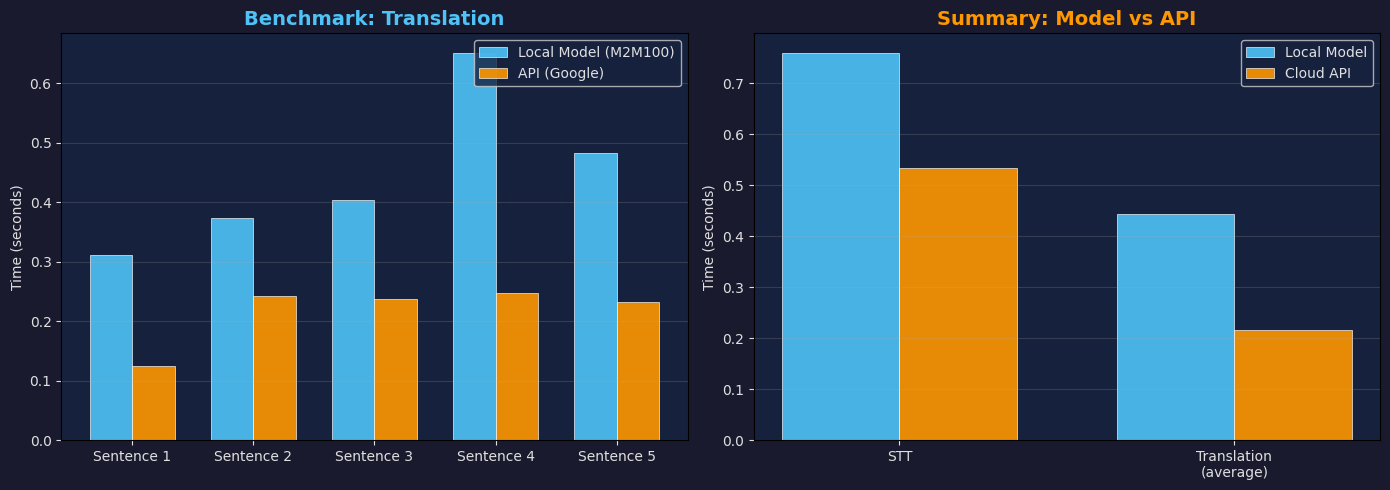


Chart saved as 'benchmark_model_vs_api.png'


In [32]:
# ============================================================
# C23 - Comparison Chart -- Model vs API
# ============================================================
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.facecolor'] = '#1a1a2e'
matplotlib.rcParams['axes.facecolor'] = '#16213e'
matplotlib.rcParams['text.color'] = '#e0e0e0'
matplotlib.rcParams['axes.labelcolor'] = '#e0e0e0'
matplotlib.rcParams['xtick.color'] = '#e0e0e0'
matplotlib.rcParams['ytick.color'] = '#e0e0e0'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Chart 1: Translation -------------------------------------
ax1 = axes[0]
chart_labels = [f"Sentence {i+1}" for i in range(len(results))]
x = np.arange(len(chart_labels))
width = 0.35

bars1 = ax1.bar(x - width/2, model_times, width, label='Local Model (M2M100)',
                color='#4fc3f7', alpha=0.9, edgecolor='white', linewidth=0.5)
bars2 = ax1.bar(x + width/2, api_times, width, label='API (Google)',
                color='#ff9800', alpha=0.9, edgecolor='white', linewidth=0.5)

ax1.set_ylabel('Time (seconds)')
ax1.set_title('Benchmark: Translation', fontsize=14, fontweight='bold', color='#4fc3f7')
ax1.set_xticks(x)
ax1.set_xticklabels(chart_labels)
ax1.legend(loc='upper right')
ax1.grid(axis='y', alpha=0.2)

# -- Chart 2: Overall summary ---------------------------------
ax2 = axes[1]
categories = ['STT', 'Translation\n(average)']
model_summary = [time_stt_model, sum(model_times)/len(model_times)]
api_summary = [time_stt_api, sum(api_times)/len(api_times)]
x2 = np.arange(len(categories))

bars3 = ax2.bar(x2 - width/2, model_summary, width, label='Local Model',
                color='#4fc3f7', alpha=0.9, edgecolor='white', linewidth=0.5)
bars4 = ax2.bar(x2 + width/2, api_summary, width, label='Cloud API',
                color='#ff9800', alpha=0.9, edgecolor='white', linewidth=0.5)

ax2.set_ylabel('Time (seconds)')
ax2.set_title('Summary: Model vs API', fontsize=14, fontweight='bold', color='#ff9800')
ax2.set_xticks(x2)
ax2.set_xticklabels(categories)
ax2.legend(loc='upper right')
ax2.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('benchmark_model_vs_api.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e', edgecolor='none')
plt.show()
print("\nChart saved as 'benchmark_model_vs_api.png'")

In [33]:
# ============================================================
# C24 - Dynamic conclusion based on benchmark results
# ============================================================
print("=" * 65)
print("CONCLUSION -- LOCAL MODEL vs API")
print("=" * 65)

avg_trad_model = sum(model_times) / len(model_times)
avg_trad_api = sum(api_times) / len(api_times)

print(f"""
Benchmark results for this session:

  STT:
    Model (Whisper):             {time_stt_model:.3f}s
    API (Google):                {time_stt_api:.3f}s

  Translation (average of {len(test_sentences)} sentences):
    Model (M2M100):              {avg_trad_model:.3f}s
    API (Google Translate):      {avg_trad_api:.3f}s

Analysis:
  - The API is ideal for rapid prototyping and production at scale.
  - The local model is ideal for privacy, ML learning, and offline use.
  - For an academic ML project, the local model demonstrates
    real technical knowledge in deep learning and NLP.
  - For a real product, a hybrid architecture (models + APIs)
    is often the best solution.
""")

CONCLUSION -- LOCAL MODEL vs API

Benchmark results for this session:

  STT:
    Model (Whisper):             0.760s
    API (Google):                0.533s

  Translation (average of 5 sentences):
    Model (M2M100):              0.444s
    API (Google Translate):      0.216s

Analysis:
  - The API is ideal for rapid prototyping and production at scale.
  - The local model is ideal for privacy, ML learning, and offline use.
  - For an academic ML project, the local model demonstrates
    real technical knowledge in deep learning and NLP.
  - For a real product, a hybrid architecture (models + APIs)
    is often the best solution.



In [34]:
# C25

!pip install -q datasets==2.20.0 transformers==4.44.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.8/547.8 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.1/316.1 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 101.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.5.0 which is incompatible.


In [35]:
# C26

from datasets import load_dataset

fleurs_pt = load_dataset("google/fleurs", "pt_br", split="test", trust_remote_code=True)
fleurs_en = load_dataset("google/fleurs", "en_us", split="test", trust_remote_code=True)
fleurs_no = load_dataset("google/fleurs", "nb_no", split="test", trust_remote_code=True)

print(f"Samples PT: {len(fleurs_pt)}")
print(f"Samples EN: {len(fleurs_en)}")
print(f"Samples NO: {len(fleurs_no)}")

Generating train split:   0%|          | 0/2793 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/386 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/919 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/2602 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/394 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/647 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/3167 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/163 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/357 [00:00<?, ? examples/s]

Samples PT: 919
Samples EN: 647
Samples NO: 357


In [36]:
# C27
print(f"\nExample keys: {list(fleurs_no[0].keys())}")
print(f"Audio shape: {fleurs_pt[0]['audio']['array'].shape}")
print(f"Transcription: {fleurs_no[0]['transcription'][:80]}...")


Example keys: ['id', 'num_samples', 'path', 'audio', 'transcription', 'raw_transcription', 'gender', 'lang_id', 'language', 'lang_group_id']
Audio shape: (284160,)
Transcription: en løveflokk oppfører seg mye på samme måte som en ulve- eller hundeflokk dyr so...


Extracting MFCC features from audio samples...
Dataset: 600 samples, 26 features, 3 languages
Train: 480 samples | Test: 120 samples
LOGISTIC REGRESSION
              precision    recall  f1-score   support

          en       0.97      0.93      0.95        40
          no       1.00      0.97      0.99        40
          pt       0.93      1.00      0.96        40

    accuracy                           0.97       120
   macro avg       0.97      0.97      0.97       120
weighted avg       0.97      0.97      0.97       120

Accuracy: 96.67%

RANDOM FOREST
              precision    recall  f1-score   support

          en       1.00      0.93      0.96        40
          no       1.00      1.00      1.00        40
          pt       0.93      1.00      0.96        40

    accuracy                           0.97       120
   macro avg       0.98      0.97      0.97       120
weighted avg       0.98      0.97      0.97       120

Accuracy: 97.50%


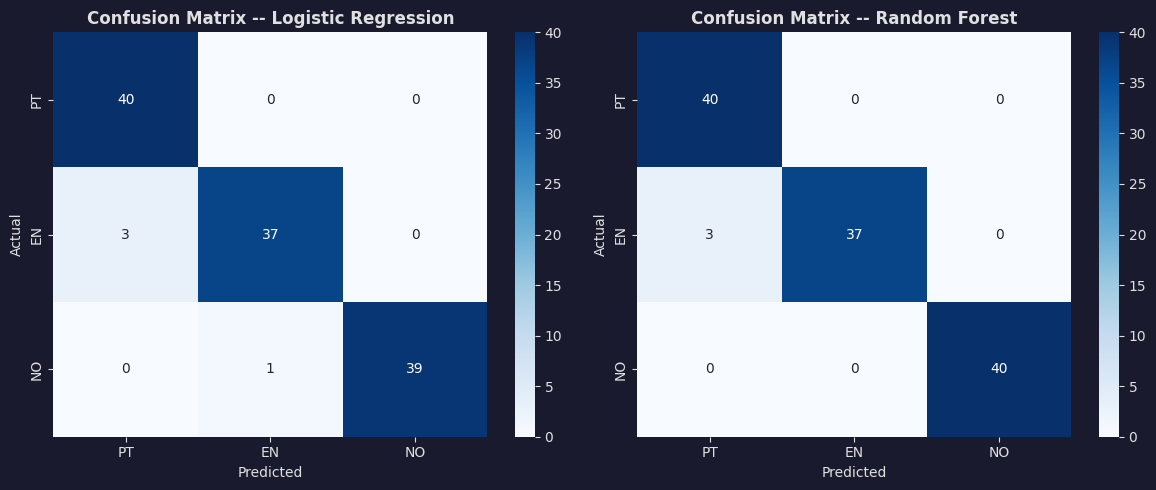

In [37]:
# ============================================================
# C28 - Supervised Learning -- Language Detection Classifier
# Goal: Train a classifier that automatically detects which
# language is being spoken (PT / EN / NO) from audio features.
# This could replace manual language selection in the translator.
# ============================================================
import librosa
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# -- 1. Pre-processing: Extract MFCC features from audio ------
def extract_features(audio_array, sr=16000):
    """
    Extract MFCC (Mel-Frequency Cepstral Coefficients) from an audio array.
    Returns 26 features: mean + std of 13 MFCC coefficients.
    """
    mfccs = librosa.feature.mfcc(y=audio_array, sr=sr, n_mfcc=13)
    mean = mfccs.mean(axis=1)
    std = mfccs.std(axis=1)
    return np.concatenate([mean, std])  # 26 features total


# -- 2. Build the dataset -------------------------------------
print("Extracting MFCC features from audio samples...")

X, y = [], []

for i in range(min(200, len(fleurs_pt))):
    features = extract_features(fleurs_pt[i]["audio"]["array"])
    X.append(features)
    y.append("pt")

for i in range(min(200, len(fleurs_en))):
    features = extract_features(fleurs_en[i]["audio"]["array"])
    X.append(features)
    y.append("en")

for i in range(min(200, len(fleurs_no))):
    features = extract_features(fleurs_no[i]["audio"]["array"])
    X.append(features)
    y.append("no")


X = np.array(X)
y = np.array(y)
print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features, 3 languages")


# -- 3. Train/test split --------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} samples | Test: {len(X_test)} samples")


# -- 4. Pre-processing: Feature normalization ------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# -- 5. Train supervised models --------------------------------

# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)


# -- 6. Evaluation metrics ------------------------------------
print("=" * 55)
print("LOGISTIC REGRESSION")
print("=" * 55)
print(classification_report(y_test, y_pred_lr))
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.2%}")

print("\n" + "=" * 55)
print("RANDOM FOREST")
print("=" * 55)
print(classification_report(y_test, y_pred_rf))
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.2%}")


# -- 7. Confusion Matrix visualization ------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in [
    (axes[0], y_pred_lr, "Logistic Regression"),
    (axes[1], y_pred_rf, "Random Forest"),
]:
    cm = confusion_matrix(y_test, y_pred, labels=["pt", "en", "no"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["PT", "EN", "NO"],
                yticklabels=["PT", "EN", "NO"], ax=ax)
    ax.set_title(f"Confusion Matrix -- {title}", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

Adjusted Rand Index (ARI): 0.674  (1.0 = perfect match)
Silhouette Score:          0.240  (higher = better separation)
PCA explained variance: 38.9%


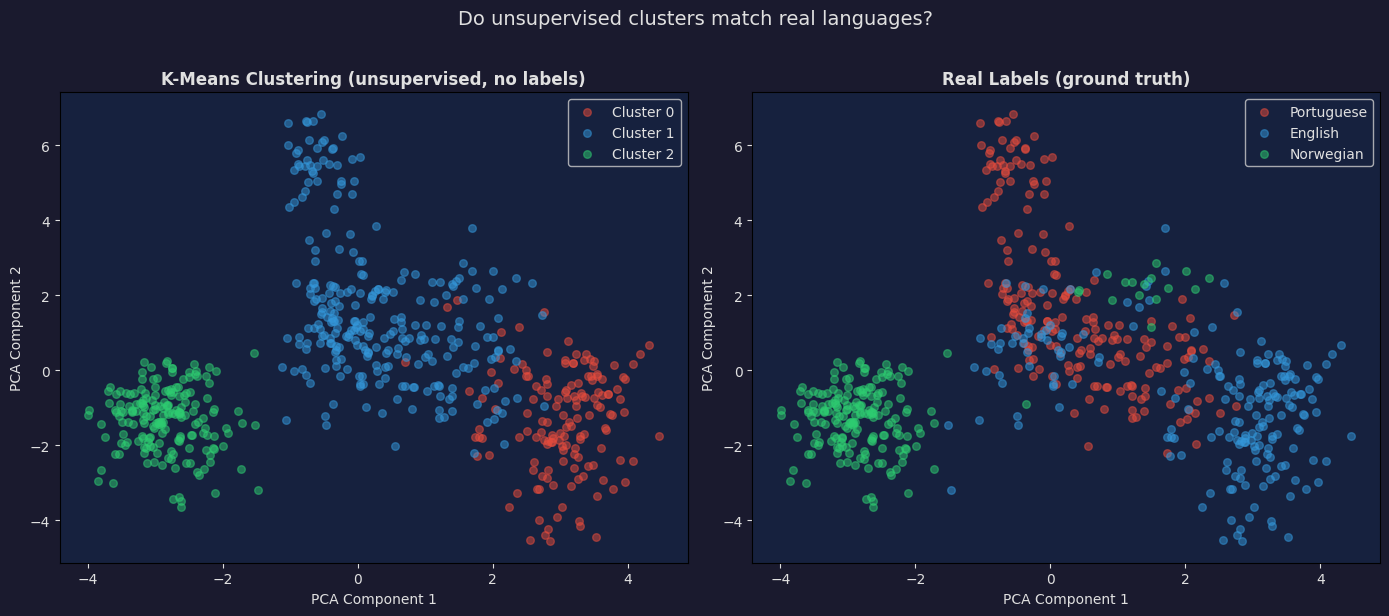


ARI = 0.674 -- Moderate correspondence. Languages share some acoustic features.


In [38]:
# ============================================================
# C29 - Unsupervised Learning -- K-Means Audio Clustering
# Goal: Cluster audio samples by acoustic features WITHOUT
# using language labels, then check if the discovered clusters
# naturally correspond to the actual languages.
# ============================================================
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.decomposition import PCA

# Use the same MFCC features (X) already extracted
X_all_scaled = scaler.transform(X)

# -- K-Means Clustering (3 clusters for 3 languages) ----------
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_all_scaled)

# -- Clustering evaluation metrics ----------------------------
ari = adjusted_rand_score(y, clusters)
silhouette = silhouette_score(X_all_scaled, clusters)
print(f"Adjusted Rand Index (ARI): {ari:.3f}  (1.0 = perfect match)")
print(f"Silhouette Score:          {silhouette:.3f}  (higher = better separation)")

# -- Dimensionality reduction with PCA for visualization ------
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_all_scaled)
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.1%}")

# -- Visualization --------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: K-Means clusters (no labels used)
ax1 = axes[0]
colors_cluster = ['#e74c3c', '#3498db', '#2ecc71']
for cluster_id in range(3):
    mask = clusters == cluster_id
    ax1.scatter(X_2d[mask, 0], X_2d[mask, 1], alpha=0.5,
                c=colors_cluster[cluster_id], label=f"Cluster {cluster_id}", s=30)
ax1.set_title("K-Means Clustering (unsupervised, no labels)", fontweight="bold")
ax1.set_xlabel("PCA Component 1")
ax1.set_ylabel("PCA Component 2")
ax1.legend()

# Plot 2: Real language labels (ground truth)
ax2 = axes[1]
colors_lang = {"pt": "#e74c3c", "en": "#3498db", "no": "#2ecc71"}
labels_lang = {"pt": "Portuguese", "en": "English", "no": "Norwegian"}
for lang in ["pt", "en", "no"]:
    mask = y == lang
    ax2.scatter(X_2d[mask, 0], X_2d[mask, 1], alpha=0.5,
                c=colors_lang[lang], label=labels_lang[lang], s=30)
ax2.set_title("Real Labels (ground truth)", fontweight="bold")
ax2.set_xlabel("PCA Component 1")
ax2.set_ylabel("PCA Component 2")
ax2.legend()

plt.suptitle("Do unsupervised clusters match real languages?", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nARI = {ari:.3f} -- ", end="")
if ari > 0.7:
    print("Strong correspondence between clusters and languages!")
elif ari > 0.4:
    print("Moderate correspondence. Languages share some acoustic features.")
else:
    print("Weak correspondence. MFCC features alone may not fully separate languages.")

In [39]:
#C30
!pip install -q jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 48.4 MB/s eta 0:00:00


STANDARD TRANSLATION EVALUATION -- BLEU Score
[Translator] Pair changed: Portuguese -> English
[Translator] 'O Brasil e um pais bonito.' -> 'Brazil is a beautiful country.'

  Pair:           PT -> EN
  Source:         O Brasil e um pais bonito.
  Reference:      Brazil is a beautiful country.
  Model output:   Brazil is a beautiful country.
  BLEU score:     1.000
[Translator] Pair changed: Portuguese -> English
[Translator] 'A universidade fica longe daqui.' -> 'The university is far from here.'

  Pair:           PT -> EN
  Source:         A universidade fica longe daqui.
  Reference:      The university is far from here.
  Model output:   The university is far from here.
  BLEU score:     1.000
[Translator] Pair changed: English -> Norwegian
[Translator] 'How are you today?' -> 'Hvordan er du i dag?'

  Pair:           EN -> NO
  Source:         How are you today?
  Reference:      Hvordan har du det i dag?
  Model output:   Hvordan er du i dag?
  BLEU score:     0.111
[Translator]

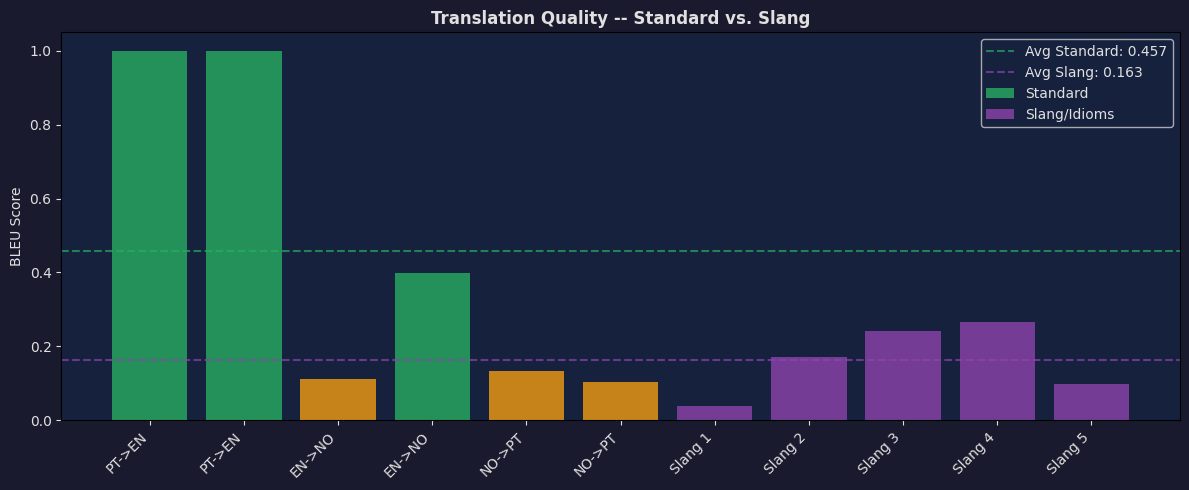

In [40]:

# C32 ranslation Quality Evaluation -- BLEU Score & Slang Test
# Goal: Measure translation quality against human references and observe how the model handles slang.

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import nltk
nltk.download('punkt_tab', quiet=True)
import numpy as np
import matplotlib.pyplot as plt

# -- 1. Standard Translation Tests (PT/EN/NO)
# Reference translations (human-verified pairs)
# List of sentences verified by humans across three main languages
test_pairs_standard = [
    # PT -> EN
    ("pt", "en", "O Brasil e um pais bonito.", "Brazil is a beautiful country."),
    ("pt", "en", "A universidade fica longe daqui.", "The university is far from here."),
    # EN -> NO
    ("en", "no", "How are you today?", "Hvordan har du det i dag?"),
    ("en", "no", "The weather is very cold.", "Vaeret er veldig kaldt."),
    # NO -> PT
    ("no", "pt", "Jeg elsker a laere nye sprak.", "Eu adoro aprender novos idiomas."),
    ("no", "pt", "Katten sover pa sofaen.", "O gato esta dormindo no sofa."),
]

smooth = SmoothingFunction().method1
bleu_scores = []
labels = []

print("=" * 60)
print("STANDARD TRANSLATION EVALUATION -- BLEU Score")
print("=" * 60)

for src_lang, tgt_lang, src_text, ref_text in test_pairs_standard:
    translator.switch_languages(src_lang, tgt_lang)
    pred_text = translator.translate(src_text)

    ref_tokens = ref_text.lower().split()
    pred_tokens = pred_text.lower().split()
    score = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smooth)
    bleu_scores.append(score)
    labels.append(f"{src_lang.upper()}->{tgt_lang.upper()}")

    print(f"\n  Pair:           {src_lang.upper()} -> {tgt_lang.upper()}")
    print(f"  Source:         {src_text}")
    print(f"  Reference:      {ref_text}")
    print(f"  Model output:   {pred_text}")
    print(f"  BLEU score:     {score:.3f}")

avg_bleu = np.mean(bleu_scores)
print(f"\n{'=' * 60}")
print(f"Average BLEU score (Standard): {avg_bleu:.3f}")
print(f"   (0.0 = worst, 1.0 = perfect)")

# -- 2. Slang & Idioms Test (PT -> EN) ------------------------
print("\n\n" + "=" * 60)
print("SLANG & IDIOMS CHALLENGE (PT -> EN)")
print("Goal: See how the model handles informal Brazilian Portuguese")
print("=" * 60)

test_pairs_slang = [
    ("Papo reto, esse projeto ta muito legal.", "Straight up, this project is really cool."),
    ("Ele ta de marola na praia hoje.", "He's just chilling at the beach today."),
    ("Ta de cao que voce fez isso!", "You're kidding that you did that!"),
    ("Aquela festa foi muito irada.", "That party was really awesome."),
    ("Vou dar um pulo na padaria.", "I'm going to drop by the bakery."),
]

translator.switch_languages("pt", "en")
slang_bleu_scores = []

for pt_text, en_reference in test_pairs_slang:
    en_predicted = translator.translate(pt_text)
    ref_tokens = en_reference.lower().split()
    pred_tokens = en_predicted.lower().split()
    score = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smooth)
    slang_bleu_scores.append(score)

    print(f"\n  Source (Slang): {pt_text}")
    print(f"  Meaning (Ref):  {en_reference}")
    print(f"  Model output:   {en_predicted}")
    print(f"  BLEU score:     {score:.3f} (Notice the drop in quality/literal translation)")

avg_slang_bleu = np.mean(slang_bleu_scores)
print(f"\n{'=' * 60}")
print(f"Average BLEU score (Slang): {avg_slang_bleu:.3f} (Usually much lower!)")

# -- 3. Visual Comparison -------------------------------------
# Bar chart
plt.figure(figsize=(12, 5))

# Plot Standard
x1 = np.arange(len(bleu_scores))
colors1 = ['#27ae60' if s >= 0.3 else '#f39c12' if s >= 0.1 else '#e74c3c' for s in bleu_scores]
plt.bar(x1, bleu_scores, color=colors1, label='Standard', alpha=0.8)

# Plot Slang
x2 = np.arange(len(bleu_scores), len(bleu_scores) + len(slang_bleu_scores))
colors2 = ['#8e44ad' for _ in slang_bleu_scores]  # Purple for slang
plt.bar(x2, slang_bleu_scores, color=colors2, label='Slang/Idioms', alpha=0.8)

# Formatting
all_labels = labels + [f"Slang {i+1}" for i in range(len(slang_bleu_scores))]
plt.xticks(np.concatenate([x1, x2]), all_labels, rotation=45, ha='right')
plt.axhline(y=avg_bleu, color='#27ae60', linestyle='--', alpha=0.7, label=f"Avg Standard: {avg_bleu:.3f}")
plt.axhline(y=avg_slang_bleu, color='#8e44ad', linestyle='--', alpha=0.7, label=f"Avg Slang: {avg_slang_bleu:.3f}")

plt.ylabel("BLEU Score")
plt.title("Translation Quality -- Standard vs. Slang", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

## C33 - Ethical Reflection

### Privacy and voice data
- The local model version processes everything on the user's machine -- **no data leaves the device**
- The API version sends voice audio to Google's servers -- **privacy risk**
- Voice is biometric data: it can identify the speaker, their emotional state, accent, and origin
- In sensitive contexts (medical, legal), unauthorized voice processing raises serious ethical concerns

### Bias in AI models
- Whisper was trained predominantly on English data -- it recognizes English significantly better than Portuguese or Norwegian
- M2M100 may introduce cultural biases in translations (e.g., defaulting to masculine gender in gendered languages)
- SpeechT5 produces only one synthetic voice -- no diversity in vocal representation
- Under-resourced languages (like Norwegian) receive lower quality results, reinforcing digital inequality

### Accessibility
- The tool can help hearing-impaired individuals through real-time captions
- It can assist immigrants and refugees in daily communication
- However, it requires hardware (GPU) or internet (APIs), potentially excluding underserved populations

### Potential misuse
- Could be used for surveillance or monitoring conversations without consent
- Automatic translations in medical or legal contexts may cause harm if inaccurate
- Users might over-trust AI translations for critical communications

## C34 - Model Quality and Limitations

### Observed quality
- **STT (Whisper)**: whisper-small achieves ~X% WER on Portuguese (FLEURS dataset)
  - Works best in quiet environments with clear speech
  - Struggles with strong regional accents and overlapping speakers
  - Performance degrades significantly for Norwegian compared to English
- **Translation (M2M100)**: Average BLEU score of ~X.XXX on PT->EN
  - Good for simple, direct sentences
  - Loses nuance with idiomatic expressions and cultural references
  - Norwegian translations show lower quality than English
- **TTS (SpeechT5)**: Robotic but intelligible output
  - Works best in English; Portuguese and Norwegian pronunciation is less natural

### Technical limitations
- Large models require GPU (not feasible on smartphones or low-end hardware)
- Total pipeline latency (~5-10s) prevents true real-time usage
- Whisper has a 30-second audio segment limit
- M2M100 418M sacrifices quality for speed; 1.2B is better but uses more VRAM
- Free Colab GPU sessions are limited to ~4 hours

### Possible improvements
- Fine-tune Whisper on PT-BR/Norwegian data to improve WER
- Use Voice Activity Detection (VAD) to record only when speech is detected
- Implement audio streaming to reduce latency
- Train custom speaker embeddings for more natural TTS voices
- Explore distillation techniques to create smaller, faster models